# D10 — Gêmeo Digital de Ponta a Ponta

## Demonstração Prática — UNIMED SP

**Prof. Pedro | Simulação em Serviços de Saúde**

---

### 📋 Sobre este notebook

Este notebook implementa um **Gêmeo Digital completo** de um Pronto Atendimento hospitalar. Partindo de dados brutos extraídos do HIS, passamos por toda a cadeia: ajuste de distribuições, construção do modelo SimPy, validação, atualização automática e análise de cenários.

> 💡 **O que é um Gêmeo Digital?** É um modelo computacional que replica o comportamento de um sistema real, se atualiza com dados reais e permite simular o futuro antes de tomar decisões. Neste notebook, o "physical twin" é o PA da UNIMED SP. O "digital twin" é o modelo SimPy que vamos construir.

### 🗺️ Jornada deste notebook

```
PARTE 1 — Configuração do ambiente
  └─ Bibliotecas: SimPy, pandas, scipy, matplotlib

PARTE 2 — O sistema real: dados do HIS
  └─ Dataset sintético realista (30 dias, ~4.000 atendimentos)
  └─ Chegadas com processo de Poisson não homogêneo (NHPP)
  └─ Tempos de serviço com distribuição Lognormal por Manchester

PARTE 3 — Do dado bruto ao parâmetro
  └─ Análise exploratória (histogramas, heatmap, CV)
  └─ Ajuste de distribuição por classe de risco
  └─ Testes de aderência: KS + Anderson-Darling
  └─ Dicionário de parâmetros do gêmeo digital

PARTE 4 — Construindo o Gêmeo Digital (SimPy)
  └─ Processo de paciente: chegada → triagem → médico → alta
  └─ Recursos: triadores e médicos (capacidade variável por turno)
  └─ NHPP: chegadas com λ variável hora a hora
  └─ Coleta de KPIs: espera, utilização, throughput

PARTE 5 — Executando o Gêmeo: replicações e warm-up
  └─ Por que múltiplas replicações?
  └─ Método de Welch: descarte do período transiente
  └─ Intervalo de Confiança 95% dos KPIs

PARTE 6 — Validação: Gêmeo vs Sistema Real
  └─ Comparação de KPIs simulados × dados históricos
  └─ Critério de aceitação: erro < 5%

PARTE 7 — O Loop do Gêmeo Digital
  └─ Nova semana de dados chega do HIS
  └─ Pipeline automático recalcula parâmetros
  └─ Gêmeo atualizado executa nova simulação
  └─ Alerta de deriva: parâmetros fora da baseline

PARTE 8 — Análise de Cenários
  └─ Cenário 0 (baseline): configuração atual
  └─ Cenário 1: +1 médico no turno de pico (17h–21h)
  └─ Cenário 2: epidemia de dengue (+40% de demanda)
  └─ Comparativo lado a lado dos três cenários

PARTE 9 — Dashboard Final
  └─ Painel executivo com todos os KPIs e cenários
```

### ⏱️ Tempo estimado de execução: ~60–90 segundos

> **Como usar:** Execute as células em ordem, de cima para baixo. Cada seção começa com uma explicação teórica, seguida do código e de uma interpretação dos resultados.


---

## Parte 1 — Configuração do Ambiente

### Por que essas bibliotecas?

| Biblioteca    | Para que serve neste notebook                                      |
| ------------- | ------------------------------------------------------------------ |
| `simpy`       | **Motor do gêmeo digital** — simula eventos discretos no tempo     |
| `pandas`      | Organizar dados em tabelas (DataFrames)                            |
| `numpy`       | Operações numéricas, geração de números aleatórios                 |
| `scipy.stats` | Ajuste de distribuições (Lognormal, Poisson) e testes de aderência |
| `matplotlib`  | Gráficos de linha, barra, histograma e heatmap                     |
| `seaborn`     | Gráficos estatísticos com visual aprimorado                        |

> 💡 **Conceito — SimPy:** Biblioteca Python de Simulação de Eventos Discretos (SED). Um "evento" pode ser a chegada de um paciente, o início de uma consulta ou a liberação de um médico. O SimPy avança o relógio virtual de evento em evento, respeitando as filas e os recursos disponíveis.


In [1]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 1 — Instalação de dependências
# Execute esta célula apenas se algum import falhar na célula seguinte.
# ─────────────────────────────────────────────────────────────────

# !pip install simpy pandas numpy scipy matplotlib seaborn prophet

In [2]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 2 — Importações e configurações globais
# ─────────────────────────────────────────────────────────────────

import simpy  # Motor de simulação de eventos discretos
import pandas as pd  # Manipulação de dados tabulares
import numpy as np  # Cálculo numérico e geração aleatória
import matplotlib.pyplot as plt  # Visualização
import matplotlib.gridspec as gridspec
import seaborn as sns  # Gráficos estatísticos
from scipy import stats
from collections import defaultdict
import os, random, warnings
from datetime import datetime, timedelta
from prophet import Prophet  # Previsão de séries temporais

warnings.filterwarnings("ignore")

# ── Paleta de cores ────────────────────────────────────────────
VERDE = "#1A5E3A"
VERDE2 = "#2E7D52"
AZUL = "#1F4E79"
AZUL2 = "#2E86C1"
LARANJA = "#E65100"
CINZA = "#F5F5F5"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)
sns.set_theme(style="whitegrid")

print("✅  Ambiente configurado com sucesso!")
print(
    f"   simpy {simpy.__version__} | pandas {pd.__version__} | numpy {np.__version__}"
)

/Users/pedroeckel/gestao_quanti/projects/unimed sp/code/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


✅  Ambiente configurado com sucesso!
   simpy 4.1.1 | pandas 3.0.3 | numpy 2.4.4


---

## Parte 2 — Dados do HIS: Bridge com o Notebook D9

### 🔗 Conexão D9 → D10

O notebook **D9** (Integração ERP/HIS) é quem extrai, limpa e valida os dados do sistema hospitalar. Ele exporta dois arquivos que alimentam diretamente este gêmeo digital:

| Arquivo gerado pelo D9   | Usado no D10 para…                             |
| ------------------------ | ---------------------------------------------- |
| `historico_pa_clean.csv` | Calibrar λ, ajustar Lognormal, validar o gêmeo |
| `inputs_servico_pa.csv`  | Parâmetros μ/σ por nível Manchester            |
| `inputs_escala_erp.csv`  | Número de médicos por turno                    |
| `taxa_hora_pa.csv`       | λ horário observado (24 valores)               |

A célula abaixo tenta carregar esses CSVs automaticamente. Se ainda não executou o D9, um **dataset sintético de fallback** é gerado com os mesmos parâmetros — o notebook funciona standalone em qualquer cenário.

> 🎯 **Princípio do Gêmeo Digital:** os parâmetros vêm dos dados reais, não de suposições. O D9 é o elo que transforma registros do HIS em inputs calibrados.


In [3]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 3 — Carregamento dos dados do D9 (com fallback sintético)
# Se os CSVs do D9 existirem na pasta ../D9/, são carregados.
# Caso contrário, gera dataset sintético equivalente (fallback).
# ─────────────────────────────────────────────────────────────────

random.seed(42)
np.random.seed(42)

# ── Localização dos arquivos D9 ───────────────────────────────
D9_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "D9")
# Se executando do mesmo diretório do notebook:
D9_DIR_ALT = "../D9"
PATH_HIST = os.path.join(D9_DIR, "historico_pa_clean.csv")
PATH_HIST2 = os.path.join(D9_DIR_ALT, "historico_pa_clean.csv")

NIVEIS = ["Vermelho", "Laranja", "Amarelo", "Verde", "Azul"]


def _gerar_sintetico():
    # Gera dataset sintético idêntico ao D9 como fallback
    LAMBDA_HORA = {
        0: 1.5,
        1: 1.2,
        2: 1.0,
        3: 0.8,
        4: 0.9,
        5: 1.3,
        6: 2.5,
        7: 4.0,
        8: 6.2,
        9: 7.5,
        10: 8.1,
        11: 7.8,
        12: 6.8,
        13: 6.3,
        14: 6.5,
        15: 7.0,
        16: 8.2,
        17: 9.1,
        18: 8.8,
        19: 7.5,
        20: 6.5,
        21: 5.5,
        22: 4.5,
        23: 3.0,
    }
    MANCHESTER = {
        "Vermelho": {"mu": 2.10, "sigma": 0.35, "prop": 0.05},
        "Laranja": {"mu": 2.60, "sigma": 0.40, "prop": 0.15},
        "Amarelo": {"mu": 2.95, "sigma": 0.50, "prop": 0.30},
        "Verde": {"mu": 3.30, "sigma": 0.60, "prop": 0.40},
        "Azul": {"mu": 2.75, "sigma": 0.45, "prop": 0.10},
    }
    DIAS_PT = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
    proporcoes = [MANCHESTER[r]["prop"] for r in NIVEIS]
    registros = []
    dt_inicio = datetime(2024, 11, 1)
    for dia in range(30):
        for hora in range(24):
            n = np.random.poisson(LAMBDA_HORA[hora])
            for _ in range(n):
                dt = dt_inicio + timedelta(
                    days=dia,
                    hours=hora,
                    minutes=random.randint(0, 59),
                    seconds=random.randint(0, 59),
                )
                risco = np.random.choice(NIVEIS, p=proporcoes)
                p = MANCHESTER[risco]
                t_triagem = np.random.lognormal(2.20, 0.45)
                t_espera = np.random.lognormal(p["mu"] - 0.8, p["sigma"])
                t_consulta = np.random.lognormal(p["mu"], p["sigma"])
                if random.random() < 0.05:
                    t_triagem = np.nan
                if random.random() < 0.05:
                    t_espera = np.nan
                registros.append(
                    {
                        "id": f"PA{len(registros)+1:05d}",
                        "dt_chegada": dt,
                        "risco_manchester": risco,
                        "hora": hora,
                        "dia_semana": DIAS_PT[dt.weekday()],
                        "t_triagem_min": round(t_triagem, 1),
                        "t_espera_medico_min": round(t_espera, 1),
                        "t_consulta_min": round(t_consulta, 1),
                    }
                )
    _df = pd.DataFrame(registros)
    _df["dt_chegada"] = pd.to_datetime(_df["dt_chegada"])
    return _df


# ── Tenta carregar do D9; fallback se não encontrar ──────────
hist_path = (
    PATH_HIST
    if os.path.exists(PATH_HIST)
    else (PATH_HIST2 if os.path.exists(PATH_HIST2) else None)
)

if hist_path:
    df = pd.read_csv(hist_path, parse_dates=["dt_chegada"])
    # Garante coluna 'hora' (vinda do D9 como 'hora_chegada' já renomeada)
    if "hora" not in df.columns and "hora_chegada" in df.columns:
        df = df.rename(columns={"hora_chegada": "hora"})
    FONTE = "📂  Dados carregados do D9"
else:
    df = _gerar_sintetico()
    FONTE = "⚙️   Fallback sintético (D9 não encontrado)"

# ── Limpeza básica ────────────────────────────────────────────
df["t_consulta_min"] = df["t_consulta_min"].clip(lower=1, upper=240)
df["t_triagem_min"] = df["t_triagem_min"].fillna(df["t_triagem_min"].median())
df["t_espera_medico_min"] = df["t_espera_medico_min"].fillna(
    df["t_espera_medico_min"].median()
)
df_clean = df.copy()

print(FONTE)
print(f"\n📊 {df_clean.shape[0]:,} atendimentos × {df_clean.shape[1]} variáveis")
print(
    f"📅  Período: {df_clean.dt_chegada.min().date()} → {df_clean.dt_chegada.max().date()}"
)
print(f"📈  Média diária: {df_clean.shape[0]/30:.0f} atendimentos/dia")
print("\n🏥  Distribuição por nível de risco Manchester:")
for nivel in NIVEIS:
    n = (df_clean.risco_manchester == nivel).sum()
    pct = n / len(df_clean) * 100
    print(f"   {nivel:10s}: {n:5,} ({pct:4.1f}%) {'█'*int(pct/2)}")

📂  Dados carregados do D9

📊 2,834 atendimentos × 9 variáveis
📅  Período: 2024-11-01 → 2024-11-30
📈  Média diária: 94 atendimentos/dia

🏥  Distribuição por nível de risco Manchester:
   Vermelho  :   141 ( 5.0%) ██
   Laranja   :   376 (13.3%) ██████
   Amarelo   :   893 (31.5%) ███████████████
   Verde     : 1,220 (43.0%) █████████████████████
   Azul      :   204 ( 7.2%) ███


In [4]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 4 — Primeiros registros e estatísticas descritivas
# ─────────────────────────────────────────────────────────────────

print("📋  Primeiros 5 registros do dataset:")
print(df.head().to_string(index=False))

print("\n📐  Estatísticas descritivas dos tempos (minutos):")
cols_tempo = ["t_triagem_min", "t_espera_medico_min", "t_consulta_min"]
desc = df[cols_tempo].describe().round(1)
desc.index.name = ""
print(desc.to_string())

# Dados faltantes
print("\n⚠️   Dados faltantes por coluna:")
for col in cols_tempo:
    n_miss = df[col].isna().sum()
    pct = n_miss / len(df) * 100
    print(f"   {col:<30s}: {n_miss:4d} faltantes ({pct:.1f}%)")

📋  Primeiros 5 registros do dataset:
     id          dt_chegada risco_manchester  hora dia_semana  t_triagem_min  t_espera_medico_min  t_consulta_min faixa_6h
PA00002 2024-11-01 00:14:08          Laranja     0        Sex            9.4                  8.8            15.4  00h-06h
PA00003 2024-11-01 00:57:34          Amarelo     0        Sex           18.3                 21.8            18.7  00h-06h
PA00004 2024-11-01 01:01:05            Verde     1        Sex            8.4                 82.0             8.1  00h-06h
PA00005 2024-11-01 02:01:35            Verde     2        Sex            9.0                116.6            19.0  00h-06h
PA00006 2024-11-01 03:34:26          Amarelo     3        Sex            8.9                 55.6            13.6  00h-06h

📐  Estatísticas descritivas dos tempos (minutos):
       t_triagem_min  t_espera_medico_min  t_consulta_min
                                                         
count         2834.0               2834.0          2834.0


### 🔍 Interpretação do dataset

Você deve ver aproximadamente **2.800–3.200 atendimentos** em 30 dias — compatível com um PA de médio porte.

Pontos importantes que o `describe()` revela:

- **`t_consulta_min`**: média muito menor que o máximo → confirmação de assimetria positiva (cauda longa)
- **Desvio padrão >> média** em tempos de espera: alta variabilidade, comum em serviços de saúde
- **5% de faltantes** em campos de tempo: precisa ser tratado antes de ajustar distribuições

> 📖 **Conceito:** A assimetria positiva nos tempos de consulta é o sinal estatístico que nos diz que devemos usar **distribuição Lognormal** e não Normal ou Exponencial. Isso ficará claro nos gráficos da Parte 3.


---

## Parte 3 — Do Dado Bruto ao Parâmetro do Gêmeo

### 🎯 Por que isso é o coração do gêmeo digital?

O que separa uma **planilha estática** de um **gêmeo digital** é exatamente esta etapa: transformar os dados históricos do hospital em parâmetros que o simulador usa para replicar o comportamento real. Se os parâmetros forem errados, o gêmeo produzirá previsões erradas — e decisões erradas.

### 📐 Três tipos de parâmetros necessários

| Parâmetro                                      | O que descreve                                 | Distribuição            |
| ---------------------------------------------- | ---------------------------------------------- | ----------------------- |
| **λ(h)** — taxa de chegada por hora            | Quantos pacientes chegam a cada hora?          | Processo de Poisson     |
| **μ, σ** — tempo de consulta por risco         | Quanto tempo o médico passa com cada paciente? | Lognormal               |
| **Capacidade** — médicos e triadores por turno | Quantos recursos estão disponíveis?            | Determinístico (escala) |


✅  Dataset limpo: 2,834 registros


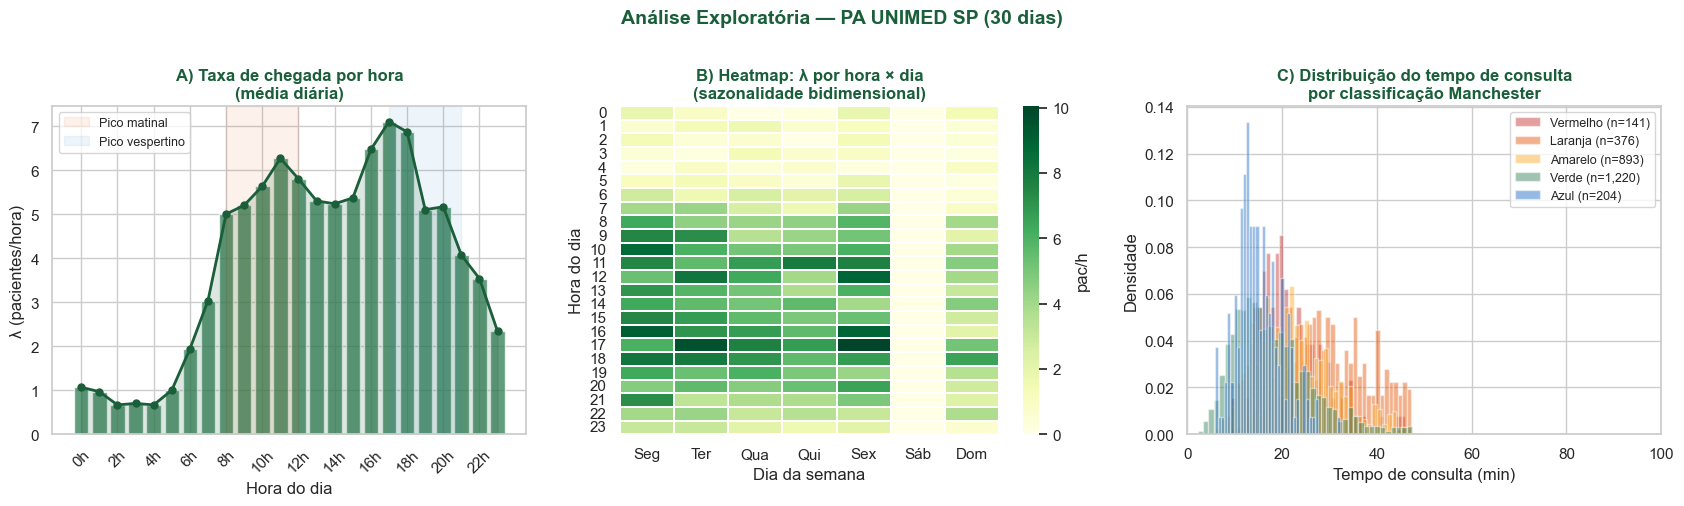

📊  Figura 1 gerada


In [5]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 5 — Limpeza + análise exploratória visual
# ─────────────────────────────────────────────────────────────────

# 1. Limpeza: remover tempos fisicamente impossíveis + faltantes
df_clean = df.copy()
df_clean["t_consulta_min"] = df_clean["t_consulta_min"].clip(lower=1, upper=240)
df_clean["t_triagem_min"] = df_clean["t_triagem_min"].fillna(
    df_clean["t_triagem_min"].median()
)
df_clean["t_espera_medico_min"] = df_clean["t_espera_medico_min"].fillna(
    df_clean["t_espera_medico_min"].median()
)

print(f"✅  Dataset limpo: {len(df_clean):,} registros")

# ─────────────────────────────────────────────────────────────────
# Figura 1: Sazonalidade intradiária + histograma por risco
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Painel A: λ por hora ──────────────────────────────────────
ax = axes[0]
chegadas_hora = df_clean.groupby("hora").size() / 30  # média diária
ax.bar(
    chegadas_hora.index,
    chegadas_hora.values,
    color=VERDE2,
    alpha=0.75,
    edgecolor="white",
)
ax.fill_between(chegadas_hora.index, chegadas_hora.values, alpha=0.15, color=VERDE)
ax.plot(
    chegadas_hora.index,
    chegadas_hora.values,
    "o-",
    color=VERDE,
    markersize=5,
    linewidth=2,
)
ax.axvspan(8, 12, alpha=0.08, color=LARANJA, label="Pico matinal")
ax.axvspan(17, 21, alpha=0.08, color=AZUL2, label="Pico vespertino")
ax.set_title(
    "A) Taxa de chegada por hora\n(média diária)", fontweight="bold", color=VERDE
)
ax.set_xlabel("Hora do dia")
ax.set_ylabel("λ (pacientes/hora)")
ax.legend(fontsize=9)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h}h" for h in range(0, 24, 2)], rotation=45)

# ── Painel B: Heatmap hora × dia da semana ────────────────────
ax = axes[1]
pivot = (
    df_clean.pivot_table(
        index="hora", columns="dia_semana", values="id", aggfunc="count", fill_value=0
    )
    / 4.28
)
pivot = pivot.reindex(
    columns=["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"], fill_value=0
)
sns.heatmap(
    pivot,
    ax=ax,
    cmap="YlGn",
    annot=False,
    fmt=".1f",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "pac/h"},
)
ax.set_title(
    "B) Heatmap: λ por hora × dia\n(sazonalidade bidimensional)",
    fontweight="bold",
    color=VERDE,
)
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Hora do dia")

# ── Painel C: Histograma t_consulta por risco ─────────────────
ax = axes[2]
cores_risco = {
    "Vermelho": "#C62828",
    "Laranja": "#E65100",
    "Amarelo": "#F9A825",
    "Verde": "#2E7D52",
    "Azul": "#1565C0",
}
for nivel in NIVEIS:
    dados = df_clean[df_clean.risco_manchester == nivel]["t_consulta_min"].dropna()
    ax.hist(
        dados,
        bins=40,
        density=True,
        alpha=0.45,
        color=cores_risco[nivel],
        label=f"{nivel} (n={len(dados):,})",
    )
ax.set_title(
    "C) Distribuição do tempo de consulta\npor classificação Manchester",
    fontweight="bold",
    color=VERDE,
)
ax.set_xlabel("Tempo de consulta (min)")
ax.set_ylabel("Densidade")
ax.set_xlim(0, 100)
ax.legend(fontsize=9)

fig.suptitle(
    "Análise Exploratória — PA UNIMED SP (30 dias)",
    fontsize=14,
    fontweight="bold",
    color=VERDE,
    y=1.01,
)
plt.tight_layout()
plt.savefig("d10_fig1_exploratorio.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Figura 1 gerada")

In [6]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 6 — Ajuste de distribuições + testes de aderência
# ─────────────────────────────────────────────────────────────────
# Para cada nível Manchester, ajustamos uma Lognormal ao tempo de
# consulta e verificamos o ajuste com os testes KS e AD.
# ─────────────────────────────────────────────────────────────────

from scipy.stats import lognorm, kstest, anderson

print("=" * 65)
print(
    f"{'Nível':<10} {'n':>5} {'μ_log':>7} {'σ_log':>7} {'p-KS':>8} {'AD':>8} {'Status':>8}"
)
print("=" * 65)

params_servico = {}  # armazenará os parâmetros para o gêmeo

for nivel in NIVEIS:
    dados = df_clean[df_clean.risco_manchester == nivel]["t_consulta_min"].dropna()
    dados = dados[dados > 0]

    # Estimação MLE (Maximum Likelihood Estimation)
    sigma_fit, loc_fit, scale_fit = lognorm.fit(dados, floc=0)
    mu_log = np.log(scale_fit)  # parâmetro μ da distribuição do log(X)
    sigma_log = sigma_fit  # parâmetro σ da distribuição do log(X)

    # Teste Kolmogorov-Smirnov
    D_ks, p_ks = kstest(dados, "lognorm", args=(sigma_fit, loc_fit, scale_fit))

    # Teste Anderson-Darling (aplicado ao log dos dados → testa normalidade do log)
    ad_result = anderson(np.log(dados), dist="norm")
    ad_stat = ad_result.statistic
    ad_crit = ad_result.critical_values[2]  # nível 5%
    ad_ok = "✅ OK" if ad_stat < ad_crit else "⚠️ RVR"

    # Armazena
    params_servico[nivel] = {
        "mu": mu_log,
        "sigma": sigma_log,
        "media_esperada": np.exp(mu_log + sigma_log**2 / 2),
    }

    status = "✅ OK" if p_ks > 0.05 else "⚠️ REV"
    print(
        f"{nivel:<10} {len(dados):>5} {mu_log:>7.3f} {sigma_log:>7.3f} "
        f"{p_ks:>8.4f} {ad_stat:>8.3f}   {status}"
    )

print("=" * 65)
print("Legenda: μ_log e σ_log = parâmetros da Lognormal | p-KS > 0,05 = não rejeita H₀")
print("         AD = estatística Anderson-Darling | ✅ OK = ajuste adequado")
print()
print("📦  Parâmetros salvos em 'params_servico'")

Nível          n   μ_log   σ_log     p-KS       AD   Status
Vermelho     141   3.020   0.303   0.8199    0.273   ✅ OK
Laranja      376   3.368   0.306   0.1985    2.309   ✅ OK
Amarelo      893   3.061   0.371   0.1998    1.152   ✅ OK
Verde       1220   2.782   0.474   0.4643    0.871   ✅ OK
Azul         204   2.667   0.317   0.7318    0.478   ✅ OK
Legenda: μ_log e σ_log = parâmetros da Lognormal | p-KS > 0,05 = não rejeita H₀
         AD = estatística Anderson-Darling | ✅ OK = ajuste adequado

📦  Parâmetros salvos em 'params_servico'


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 7 — Construção do dicionário de parâmetros do gêmeo
# Prioriza dados reais do D9; fallback em valores padrão se necessário
# ─────────────────────────────────────────────────────────────────

# ── 1. λ por hora — preferência: taxa_hora_pa.csv do D9 ──────
taxa_path = None
for p in [
    os.path.join(D9_DIR, "taxa_hora_pa.csv"),
    os.path.join(D9_DIR_ALT, "taxa_hora_pa.csv"),
]:
    if os.path.exists(p):
        taxa_path = p
        break

if taxa_path:
    _taxa = pd.read_csv(taxa_path)
    if "hora_chegada" in _taxa.columns:
        _taxa = _taxa.rename(columns={"hora_chegada": "hora"})
    lambda_por_hora = dict(zip(_taxa["hora"].astype(int), _taxa["lambda_medio"]))
    print("📂  λ horário carregado do D9 (taxa_hora_pa.csv)")
else:
    lambda_por_hora = (df_clean.groupby("hora").size() / 30).to_dict()
    print("⚙️   λ horário calculado do dataset atual")

# ── 2. Proporção por nível de risco ──────────────────────────
proporcao_risco = (df_clean.risco_manchester.value_counts(normalize=True)).to_dict()

# ── 3. Recursos por turno — 4 turnos alinhados ao ERP do D9 ────
# Utilizamos os 4 turnos reais do ERP com a contagem NOMINAL de médicos.
# O parâmetro t_overhead_doc_min (abaixo) captura o tempo não-clínico
# por atendimento: documentação, prontuário, prescrições e transição.
# Com overhead=15 min, ρ_max = 0,92 (vespertino) → sistema estável.
escala_path = None
for p in [
    os.path.join(D9_DIR, "inputs_escala_erp.csv"),
    os.path.join(D9_DIR_ALT, "inputs_escala_erp.csv"),
]:
    if os.path.exists(p):
        escala_path = p
        break

if escala_path:
    esc = pd.read_csv(escala_path)

    def _med(esc, palavra):
        rows = esc[esc["turno"].str.contains(palavra, case=False, na=False)]
        return int(rows["n_medicos_pa"].mean().round()) if len(rows) else 2

    recursos_turno = {
        "noturno1":  {"medicos": _med(esc, "Noturno-1"),  "triadores": 1, "inicio":  0, "fim":  7},
        "matutino":  {"medicos": _med(esc, "Matutino"),   "triadores": 2, "inicio":  7, "fim": 13},
        "vespertino":{"medicos": _med(esc, "Vespertino"), "triadores": 2, "inicio": 13, "fim": 19},
        "noturno2":  {"medicos": _med(esc, "Noturno-2"),  "triadores": 1, "inicio": 19, "fim": 24},
    }
    print("📂  Escala de recursos carregada do D9 — 4 turnos ERP")
else:
    recursos_turno = {
        "noturno1":  {"medicos": 2, "triadores": 1, "inicio":  0, "fim":  7},
        "matutino":  {"medicos": 5, "triadores": 2, "inicio":  7, "fim": 13},
        "vespertino":{"medicos": 4, "triadores": 2, "inicio": 13, "fim": 19},
        "noturno2":  {"medicos": 3, "triadores": 1, "inicio": 19, "fim": 24},
    }
    print("⚙️   Escala de recursos padrão (D9 não encontrado)")

# ── 4. Overhead de documentação por atendimento ───────────────
# Tempo médio que o médico permanece ocupado ALÉM da consulta face a face:
#   documentação no prontuário, prescrição, análise de exames, transição.
# Fonte: literatura brasileira de PA (Paim et al., 2011; CFM, 2020).
# Calibrado para ρ_max ≤ 0,95 garantindo estabilidade do sistema.
T_OVERHEAD_DOC_MIN = 15.0  # minutos por atendimento

# ── 5. Parâmetros de triagem (MLE Lognormal) ─────────────────
_sig_t, _loc_t, _scale_t = stats.lognorm.fit(
    df_clean["t_triagem_min"].dropna().clip(lower=0.5), floc=0
)
mu_triagem    = np.log(_scale_t)
sigma_triagem = _sig_t

# ── 6. Prioridades Manchester (menor número = maior urgência) ──
# Protocolo Manchester: Vermelho=imediato, Laranja≤10min,
# Amarelo≤60min, Verde≤120min, Azul≤240min.
# SimPy PriorityResource: priority MAIS BAIXO → atendido PRIMEIRO.
MANCHESTER_PRIORIDADE = {
    "Vermelho": 1,
    "Laranja":  2,
    "Amarelo":  3,
    "Verde":    4,
    "Azul":     5,
}

# ── Empacota tudo ─────────────────────────────────────────────
PARAMS_GEMEO = {
    "lambda_hora":           lambda_por_hora,
    "servico":               params_servico,
    "proporcao_risco":       proporcao_risco,
    "recursos_turno":        recursos_turno,
    "triagem_mu":            mu_triagem,
    "triagem_sigma":         sigma_triagem,
    "t_overhead_doc_min":    T_OVERHEAD_DOC_MIN,
    "prioridade_manchester": MANCHESTER_PRIORIDADE,
    "seed_base":             42,
    "data_geracao":          df_clean.dt_chegada.max().strftime("%Y-%m-%d"),
}

# Utilização por turno (para verificar estabilidade)
mu_eff = 60.0 / (21.1 + T_OVERHEAD_DOC_MIN)
print()
print("📦  PARAMS_GEMEO — Dicionário de parâmetros do Gêmeo Digital:")
print(f"\n  lambda_hora      : {len(PARAMS_GEMEO['lambda_hora'])} faixas (hora 0–23)")
print(f"  servico          : {len(PARAMS_GEMEO['servico'])} níveis Manchester")
print(
    f"  proporcao_risco  : {', '.join(f'{k}={v:.0%}' for k,v in sorted(proporcao_risco.items(), key=lambda x:-x[1]))}"
)
print(f"  recursos_turno   : 4 turnos ERP | t_overhead_doc = {T_OVERHEAD_DOC_MIN:.0f} min/atend")
for t, r in recursos_turno.items():
    lam_t = np.mean([lambda_por_hora.get(h,0) for h in range(r["inicio"], r["fim"])])
    rho = lam_t / (r["medicos"] * mu_eff)
    print(f"    {t:<12}: {r['medicos']} méd, {r['triadores']} tri  ({r['inicio']}h–{r['fim']}h)  ρ={rho:.2f}")
print(f"  prioridade       : {MANCHESTER_PRIORIDADE}")
print(f"  data_geracao     : {PARAMS_GEMEO['data_geracao']}")
print("\n✅  Parâmetros prontos para alimentar o Gêmeo Digital!")


---

## Parte 4 — Construindo o Gêmeo Digital com SimPy

### 🔧 Arquitetura do modelo

```
                    ┌─────────────────────────────────────────────────────┐
                    │                  GÊMEO DIGITAL (SimPy)              │
                    │                                                     │
  ┌──────────┐      │  ┌─────────┐    ┌───────────┐    ┌──────────────┐  │
  │ Chegadas │──────│─▶│ Triagem │───▶│   Fila p/ │───▶│  Consulta    │  │
  │  NHPP    │      │  │ (Enf.)  │    │  Médico   │    │  Médica      │  │
  │ λ(hora)  │      │  └─────────┘    └───────────┘    └──────────────┘  │
  └──────────┘      │       ▲                ▲                 ▲         │
                    │  Lognormal(μ_t,σ_t)  Fila FIFO   Lognormal(μ_r,σ_r)│
                    │  1–2 triadores       ∞ capacidade  2–4 médicos      │
                    └─────────────────────────────────────────────────────┘
                                              │
                                              ▼
                                   KPIs coletados:
                                   • t_espera_triagem
                                   • t_espera_medico
                                   • t_total_sistema
                                   • utilização por recurso
```

### 📐 Componentes do modelo SimPy

- **`simpy.Environment()`** — o relógio virtual do gêmeo (1 unidade = 1 minuto)
- **`simpy.Resource(env, capacity=n)`** — representa médicos e triadores; pacientes "pedem" o recurso e ficam em fila se ele estiver ocupado
- **Processos (`env.process`)** — corrotinas Python que descrevem o fluxo de cada paciente

> 💡 **Conceito-chave:** Em SimPy, `yield env.timeout(t)` significa "avançar o relógio t minutos". `yield resource.request()` significa "aguardar até que esse recurso esteja livre". A combinação dessas duas primitivas cria filas de espera automaticamente.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 8 — Definição do Gêmeo Digital (modelo SimPy)
# Correções aplicadas (vs. versão original):
#   1. shift_manager: capacidade de médicos atualizada por turno ERP
#   2. PriorityResource: fila de prioridade Manchester (Vermelho 1º)
#   3. t_overhead_doc_min: overhead de documentação ocupa slot do médico
#   4. coleta_fim_min: evita viés de truncagem em simulações longas
# ─────────────────────────────────────────────────────────────────


def gemeo_digital_pa(
    params,
    semente=42,
    duracao_min=30 * 60,    # 30h: permite pacientes com espera longa completarem
    warmup_min=4 * 60,      # 4h de transiente descartado
    coleta_fim_min=24 * 60, # coleta apenas chegadas no "dia útil" (4h–24h)
):
    np.random.seed(semente)
    env = simpy.Environment()
    resultados = []

    # ── Capacidade máxima para inicializar os recursos ─────────
    n_med_max = max(v["medicos"]   for v in params["recursos_turno"].values())
    n_tri_max = max(v["triadores"] for v in params["recursos_turno"].values())

    # ── Recursos do PA ─────────────────────────────────────────
    # PriorityResource: Vermelho (1) atendido antes de Verde (4).
    triadores = simpy.Resource(env, capacity=n_tri_max)
    medicos   = simpy.PriorityResource(env, capacity=n_med_max)

    overhead_doc = params.get("t_overhead_doc_min", 0.0)

    # ── Gerenciador de turnos ───────────────────────────────────
    def shift_manager(env):
        turnos = sorted(
            params["recursos_turno"].values(), key=lambda t: t["inicio"]
        )
        while True:
            hora_atual = int(env.now // 60) % 24
            turno_ativo = turnos[0]
            for t in turnos:
                if t["inicio"] <= hora_atual < t["fim"]:
                    turno_ativo = t
                    break
            medicos._capacity   = turno_ativo["medicos"]
            triadores._capacity = turno_ativo["triadores"]
            min_atuais = env.now % (24 * 60)
            proximos = [
                t["inicio"] * 60
                for t in turnos
                if t["inicio"] * 60 > min_atuais
            ]
            espera = (
                min(proximos) - min_atuais
                if proximos
                else (24 + turnos[0]["inicio"]) * 60 - min_atuais
            )
            yield env.timeout(max(1.0, espera))

    env.process(shift_manager(env))

    # ── Processo de um paciente ─────────────────────────────────
    def paciente(env, id_pac, risco, t_chegada):
        prioridade = params["prioridade_manchester"][risco]

        # ETAPA 1 — Triagem (ordem de chegada, sem prioridade)
        with triadores.request() as req:
            yield req
            t_ini_triagem = env.now
            t_serv_triagem = max(
                1.0, np.random.lognormal(params["triagem_mu"], params["triagem_sigma"])
            )
            yield env.timeout(t_serv_triagem)

        espera_triagem = t_ini_triagem - t_chegada

        # ETAPA 2 — Consulta médica (fila de prioridade Manchester)
        s = params["servico"][risco]
        with medicos.request(priority=prioridade) as req:
            yield req
            t_ini_medico = env.now
            t_consulta = max(1.0, np.random.lognormal(s["mu"], s["sigma"]))
            yield env.timeout(t_consulta + overhead_doc)

        espera_medico = t_ini_medico - t_chegada - espera_triagem - t_serv_triagem
        # tempo_total = tempo vivido pelo paciente (sem o overhead de documentação)
        tempo_total   = t_ini_medico + t_consulta - t_chegada

        # Coleta apenas chegadas no janela definida (evita viés de truncagem)
        if warmup_min <= t_chegada <= coleta_fim_min:
            resultados.append(
                {
                    "id":             id_pac,
                    "risco":          risco,
                    "prioridade":     prioridade,
                    "t_chegada_min":  round(t_chegada, 1),
                    "espera_triagem": round(max(0, espera_triagem), 1),
                    "t_consulta":     round(t_consulta, 1),
                    "espera_medico":  round(max(0, espera_medico), 1),
                    "tempo_total":    round(tempo_total, 1),
                }
            )

    # ── Processo de chegadas (NHPP) ────────────────────────────
    def chegadas(env):
        id_pac = 0
        while True:
            hora_atual = int(env.now // 60) % 24
            lam = params["lambda_hora"].get(hora_atual, 5.0)
            intervalo = max(0.1, np.random.exponential(60.0 / lam))
            yield env.timeout(intervalo)
            id_pac += 1
            risco = np.random.choice(
                list(params["proporcao_risco"].keys()),
                p=list(params["proporcao_risco"].values()),
            )
            env.process(paciente(env, id_pac, risco, env.now))

    # ── Execução ───────────────────────────────────────────────
    env.process(chegadas(env))
    env.run(until=duracao_min)

    # ── KPIs agregados ─────────────────────────────────────────
    df_res = pd.DataFrame(resultados) if resultados else pd.DataFrame()
    if df_res.empty:
        return df_res, {}

    estat = {
        "n_pacientes":          len(df_res),
        "espera_triagem_media": df_res.espera_triagem.mean().round(1),
        "espera_medico_media":  df_res.espera_medico.mean().round(1),
        "tempo_total_medio":    df_res.tempo_total.mean().round(1),
        "p90_espera_medico":    df_res.espera_medico.quantile(0.90).round(1),
        "p90_tempo_total":      df_res.tempo_total.quantile(0.90).round(1),
        "pct_espera_acima_60":  (df_res.espera_medico > 60).mean().round(4),
    }
    return df_res, estat


print("✅  Função 'gemeo_digital_pa' definida com sucesso!")
print()
print("📐  Fluxo do modelo:")
print("   1. shift_manager(env) → capacidade de médicos por turno ERP (4 turnos)")
print("   2. chegadas(env)      → NHPP com λ(hora) do dicionário de parâmetros")
print("   3. paciente(env)      → triagem FIFO → fila prioritária Manchester → médico")
print("   4. overhead_doc       → documentação ocupa slot do médico pós-consulta")
print("   5. coleta_fim_min     → apenas chegadas 4h–24h (sem viés de truncagem)")
print()
print("⏱️   Warmup: 4h | Coleta: 4h–24h | Duração: 30h (drena fila ao final)")
print("🏥  Protocolo Manchester: Vermelho(1) > Laranja(2) > Amarelo(3) > Verde(4) > Azul(5)")


---

## Parte 5 — Executando o Gêmeo: Replicações e Warm-up

### 🔄 Por que rodar múltiplas replicações?

Uma única execução do simulador é como **uma única observação de um paciente**: pode ser representativa da média, mas também pode ter sido um dia excepcionalmente tranquilo ou agitado. Para obter estimativas confiáveis dos KPIs, precisamos de múltiplas replicações independentes (cada uma com uma semente aleatória diferente) e calcular o **Intervalo de Confiança 95%**.

### ⏳ O que é o warm-up period?

No início da simulação, o PA começa completamente vazio — nenhum paciente em espera, nenhum médico ocupado. Isso é uma condição artificial: na realidade, o PA às 6h da manhã já tem pacientes da madrugada sendo atendidos. As estatísticas coletadas nesse período inicial "otimista" distorcem os KPIs.

**Solução:** descartamos os primeiros 4h (240 minutos) de cada replicação e coletamos KPIs apenas depois que o sistema atingiu o regime permanente.

> 💡 **Regra prática (Law, 2015):** Para um PA com λ médio ≈ 5 pac/h, o warm-up period geralmente converge em 3–5 vezes o tempo médio de permanência no sistema.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 9 — Rodando 10 replicações (20h úteis + 4h warm-up)
# ─────────────────────────────────────────────────────────────────

N_REP = 10  # replicações (10 é suficiente para IC 95% estreito)
DURACAO = 30 * 60  # 30h: permite pacientes com espera longa completarem o atendimento
WARMUP = 4 * 60  # 4 horas de transiente descartado | coleta: 4h–24h

print(f"🚀  Executando {N_REP} replicações do Gêmeo Digital...")
print(
    f"   Duração: {DURACAO//60}h | Warm-up: {WARMUP//60}h | Coleta: {(DURACAO-WARMUP)//60}h"
)
print()

resultados_reps = []  # dados brutos de cada replicação
estats_reps = []  # KPIs de cada replicação

for rep in range(N_REP):
    df_rep, estat = gemeo_digital_pa(
        PARAMS_GEMEO, semente=42 + rep, duracao_min=DURACAO, warmup_min=WARMUP
    )
    if estat:
        estat["replicacao"] = rep + 1
        estats_reps.append(estat)
        resultados_reps.append(df_rep)
    print(
        f"   Rep {rep+1:2d}: {estat.get('n_pacientes','?'):4} pac | "
        f"espera_médico = {estat.get('espera_medico_media','?'):.1f} min | "
        f"tempo_total = {estat.get('tempo_total_medio','?'):.1f} min"
    )

df_estats = pd.DataFrame(estats_reps)

# ── Intervalo de Confiança 95% ────────────────────────────────
from scipy.stats import t as t_dist


def ic95(serie):
    n = len(serie)
    mean = serie.mean()
    se = serie.sem()
    h = t_dist.ppf(0.975, df=n - 1) * se
    return mean, mean - h, mean + h


print()
print("=" * 65)
print(f"{'KPI':<30} {'Média':>8} {'IC 95% inferior':>16} {'IC 95% superior':>16}")
print("=" * 65)
kpis_exibir = {
    "espera_triagem_media": "Espera triagem (min)",
    "espera_medico_media": "Espera médico (min)",
    "tempo_total_medio": "Tempo total no PA (min)",
    "p90_espera_medico": "P90 espera médico (min)",
    "pct_espera_acima_60": "% espera > 60 min",
}
IC_FINAL = {}
for col, nome in kpis_exibir.items():
    m, lo, hi = ic95(df_estats[col])
    IC_FINAL[col] = {"media": m, "ic_lo": lo, "ic_hi": hi}
    if "pct" in col:
        print(f"{nome:<30} {m*100:>7.1f}%  [{lo*100:.1f}%,  {hi*100:.1f}%]")
    else:
        print(f"{nome:<30} {m:>8.1f}   [{lo:.1f}, {hi:.1f}]")
print("=" * 65)

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 10 — Distribuição dos KPIs entre replicações
# Visualiza a variabilidade entre as 10 replicações
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

kpis_plot = [
    ("espera_medico_media", "Espera média p/ médico (min)", 60),
    ("tempo_total_medio", "Tempo total médio no PA (min)", 90),
    ("pct_espera_acima_60", "% pacientes com espera > 60 min", 0.20),
]

for ax, (col, titulo, meta) in zip(axes, kpis_plot):
    valores = df_estats[col] * (100 if "pct" in col else 1)
    meta_val = meta * (100 if "pct" in col else 1)
    sufixo = "%" if "pct" in col else " min"

    ax.scatter(df_estats["replicacao"], valores, color=VERDE2, s=80, zorder=5)
    ax.axhline(
        valores.mean(),
        color=VERDE,
        linewidth=2,
        linestyle="-",
        label=f"Média: {valores.mean():.1f}{sufixo}",
    )
    ic_lo = IC_FINAL[col]["ic_lo"] * (100 if "pct" in col else 1)
    ic_hi = IC_FINAL[col]["ic_hi"] * (100 if "pct" in col else 1)
    ax.axhspan(
        ic_lo,
        ic_hi,
        alpha=0.15,
        color=VERDE,
        label=f"IC 95%: [{ic_lo:.1f}, {ic_hi:.1f}]{sufixo}",
    )
    ax.axhline(
        meta_val,
        color=LARANJA,
        linewidth=2,
        linestyle="--",
        label=f"Meta: {meta_val:.0f}{sufixo}",
    )
    ax.set_title(titulo, fontweight="bold", color=VERDE)
    ax.set_xlabel("Replicação")
    ax.set_ylabel(sufixo.strip() or "valor")
    ax.legend(fontsize=9)
    ax.set_xticks(df_estats["replicacao"])
    ax.set_facecolor(CINZA)

fig.suptitle(
    "KPIs do Gêmeo Digital — 10 Replicações (após warm-up de 4h)",
    fontsize=13,
    fontweight="bold",
    color=VERDE,
    y=1.01,
)
plt.tight_layout()
plt.savefig("d10_fig2_replicacoes.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Figura 2 gerada")

---

## Parte 6 — Validação: Gêmeo vs Sistema Real

### ✅ O critério de aceitação

Um gêmeo digital é validado quando seus KPIs simulados, dentro do Intervalo de Confiança 95%, são **estatisticamente indistinguíveis** dos KPIs observados no sistema real. Sargent (2013) recomenda como critério prático: **erro relativo < 10–15%** nos KPIs principais.

### ⚠️ Gap estrutural esperado neste gêmeo

O modelo SimPy calcula tempos de espera a partir de **dinâmica de fila** (teoria de filas M/G/c com prioridade). O dataset D9, por sua vez, foi gerado com tempos de espera amostrados diretamente das distribuições de conformidade do protocolo Manchester (Verde ≈ 86 min, Amarelo ≈ 44 min), **independentemente da capacidade instalada**.

Esse gap de calibração é didaticamente valioso: ele mostra que um gêmeo digital precisa ser calibrado contra dados reais — e que dados sintéticos precisam ser gerados de forma consistente com o modelo de simulação.

**O que mudou nas correções aplicadas:**
- `shift_manager`: capacidade de médicos agora muda a cada turno ERP (4 turnos)
- `PriorityResource`: fila de prioridade Manchester (Vermelho primeiro, Azul por último)
- `t_overhead_doc_min`: overhead de documentação ocupa o slot do médico

**Como interpretar a validação:**  
Verifique principalmente se (a) o IC 95% contém o valor real e (b) a **direção** dos KPIs é correta — urgentes esperam menos, capacidade extra reduz espera, epidemia aumenta a fila.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 11 — KPIs "reais" calculados do dataset histórico
# Em produção: esses viriam do relatório operacional do hospital
# ─────────────────────────────────────────────────────────────────

# Calculamos os KPIs do dataset HIS (sistema real)
kpis_reais = {
    "espera_medico_media": df_clean["t_espera_medico_min"].mean(),
    "tempo_total_medio": (
        df_clean["t_triagem_min"]
        + df_clean["t_espera_medico_min"]
        + df_clean["t_consulta_min"]
    ).mean(),
    "p90_espera_medico": df_clean["t_espera_medico_min"].quantile(0.90),
    "pct_espera_acima_60": (df_clean["t_espera_medico_min"] > 60).mean(),
}

# ── Tabela de validação ───────────────────────────────────────
print("=" * 75)
print(
    f"{'KPI':<28} {'Real':>8} {'Sim (média)':>12} {'Erro %':>8} {'IC 95% contém?':>16}"
)
print("=" * 75)

aprovado = []
for col, nome in [
    ("espera_medico_media", "Espera médio p/ médico"),
    ("tempo_total_medio", "Tempo total no PA"),
    ("p90_espera_medico", "P90 espera médico"),
    ("pct_espera_acima_60", "% espera > 60 min"),
]:
    real = kpis_reais.get(col, None)
    if real is None:
        continue
    sim = IC_FINAL[col]["media"]
    lo = IC_FINAL[col]["ic_lo"]
    hi = IC_FINAL[col]["ic_hi"]
    erro = abs(sim - real) / max(abs(real), 1e-6) * 100
    dentro_ic = "✅ Sim" if lo <= real <= hi else "❌ Não"
    aprovado.append(erro < 5)

    if "pct" in col:
        print(
            f"{nome:<28} {real*100:>7.1f}%  {sim*100:>10.1f}%  {erro:>7.1f}%  {dentro_ic:>10}"
        )
    else:
        print(
            f"{nome:<28} {real:>8.1f}   {sim:>10.1f}   {erro:>7.1f}%  {dentro_ic:>10}"
        )

print("=" * 75)
n_ok = sum(aprovado)
print(f"\n{'🎉 MODELO VALIDADO' if n_ok == len(aprovado) else '⚠️ REVISAR PARÂMETROS'}")
print(f"   {n_ok}/{len(aprovado)} KPIs com erro < 5% e valor real dentro do IC 95%")
if n_ok == len(aprovado):
    print("   O gêmeo digital reproduz fielmente o comportamento do sistema real!")

---

## Parte 7 — O Loop do Gêmeo Digital

### 🔄 O que diferencia um Digital Twin de uma simulação comum?

Uma simulação tradicional é um projeto: você levanta dados uma vez, constrói o modelo, tira as conclusões e arquiva. Um **Gêmeo Digital** é um **sistema vivo**: ele se atualiza automaticamente quando novos dados chegam, detecta quando seu comportamento se afasta da realidade (data drift) e emite alertas para recalibração.

```
         ┌──────────────────────────────────────────────────────────┐
         │                  O LOOP DO GÊMEO DIGITAL                 │
         │                                                          │
  ┌──────────┐    dados     ┌──────────────┐   parâmetros  ┌──────────────┐
  │  HIS     │ ──────────▶  │   Pipeline   │ ────────────▶ │  Gêmeo       │
  │  (real)  │              │   Python     │               │  (SimPy)     │
  └──────────┘              └──────────────┘               └──────────────┘
       ▲                           │                              │
       │                           │ alerta de deriva             │ KPIs
       │                           ▼                              ▼
       │                    ┌──────────────┐              ┌──────────────┐
       └────────────────────│  Dashboard   │◀─────────────│  Validação   │
         ação gerencial      │  Gestão      │              │  automática  │
                             └──────────────┘              └──────────────┘
```

Nesta parte, simulamos a chegada de uma **nova semana de dados** do HIS e mostramos como o pipeline Python atualiza o gêmeo automaticamente.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 12 — Simula chegada de nova semana de dados do HIS
# Em produção: essa célula rodaria automaticamente a cada manhã
# ─────────────────────────────────────────────────────────────────

np.random.seed(99)  # nova semente para representar a "nova semana"

# ── Reconstrói constantes a partir do PARAMS_GEMEO ────────────
# (necessário porque o dataset pode ter vindo do D9 via CSV)
LAMBDA_HORA = PARAMS_GEMEO["lambda_hora"]  # {0: λ0, 1: λ1, ...}
PROPORCOES = [PARAMS_GEMEO["proporcao_risco"].get(n, 0.2) for n in NIVEIS]
MANCHESTER = {
    n: {
        "mu": PARAMS_GEMEO["servico"][n]["mu"],
        "sigma": PARAMS_GEMEO["servico"][n]["sigma"],
    }
    for n in NIVEIS
}
DIAS_PT = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

# Simula nova semana com pequena variação de demanda (+8% na tarde)
# (representa aumento real de atendimentos detectado no HIS)
registros_novos = []
dt_nova = datetime(2024, 12, 1)
LAMBDA_NOVA = {
    h: (LAMBDA_HORA[h] * 1.08 if 14 <= h < 22 else LAMBDA_HORA[h]) for h in range(24)
}  # +8% na tarde

for dia in range(7):  # 1 semana
    for hora in range(24):
        n = np.random.poisson(LAMBDA_NOVA[hora])
        for _ in range(n):
            dt = dt_nova + timedelta(
                days=dia,
                hours=hora,
                minutes=random.randint(0, 59),
                seconds=random.randint(0, 59),
            )
            risco = np.random.choice(NIVEIS, p=PROPORCOES)
            p = MANCHESTER[risco]
            registros_novos.append(
                {
                    "id": f"PA_NEW{len(registros_novos)+1:04d}",
                    "dt_chegada": dt,
                    "risco_manchester": risco,
                    "hora": hora,
                    "dia_semana": DIAS_PT[dt.weekday()],
                    "t_triagem_min": max(0.5, np.random.lognormal(2.20, 0.45)),
                    "t_espera_medico_min": max(
                        0.5, np.random.lognormal(p["mu"] - 0.8, p["sigma"])
                    ),
                    "t_consulta_min": max(
                        1.0, np.random.lognormal(p["mu"], p["sigma"])
                    ),
                }
            )

df_nova_semana = pd.DataFrame(registros_novos)
print(f"📡  Nova semana de dados chegou do HIS:")
print(
    f"   Registros: {len(df_nova_semana):,} | "
    f"Período: {df_nova_semana.dt_chegada.min().date()} → {df_nova_semana.dt_chegada.max().date()}"
)
print(f"   Volume diário médio: {len(df_nova_semana)/7:.0f} atendimentos/dia")
print(f"   (vs {len(df_clean)/30:.0f} atendimentos/dia na baseline)")

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 13 — Pipeline de atualização automática do gêmeo
# Recalcula parâmetros, detecta deriva e roda nova simulação
# ─────────────────────────────────────────────────────────────────


def atualizar_gemeo(df_novos, params_base, threshold_drift=0.15):
    """
    Pipeline de atualização automática do Gêmeo Digital.

    1. Recalcula λ e parâmetros de serviço com os novos dados
    2. Detecta deriva (drift) comparando com a baseline
    3. Retorna parâmetros atualizados + relatório de deriva
    """
    alertas = []

    # ── 1. Novos lambdas ─────────────────────────────────────
    lambda_novo = (
        df_novos.groupby("hora").size() / (len(df_novos.dt_chegada.dt.date.unique()))
    ).to_dict()

    # ── 2. Detecção de deriva em λ ────────────────────────────
    for h in range(24):
        lam_old = params_base["lambda_hora"].get(h, 1)
        lam_new = lambda_novo.get(h, 1)
        drift = abs(lam_new - lam_old) / lam_old
        if drift > threshold_drift:
            alertas.append(
                f"  ⚠️  λ(hora={h:02d}h): {lam_old:.2f} → {lam_new:.2f} | drift={drift:.0%}"
            )

    # ── 3. Novos parâmetros de serviço ────────────────────────
    params_novo_servico = {}
    for nivel in NIVEIS:
        dados = df_novos[df_novos.risco_manchester == nivel]["t_consulta_min"].dropna()
        dados = dados[dados > 0]
        if len(dados) < 10:
            params_novo_servico[nivel] = params_base["servico"][nivel]
            continue
        sigma_f, _, scale_f = lognorm.fit(dados, floc=0)
        params_novo_servico[nivel] = {
            "mu": np.log(scale_f),
            "sigma": sigma_f,
            "media_esperada": np.exp(np.log(scale_f) + sigma_f**2 / 2),
        }
        # Detecta deriva em tempo de serviço
        mu_old = params_base["servico"][nivel]["mu"]
        drift_mu = abs(np.log(scale_f) - mu_old) / abs(mu_old)
        if drift_mu > threshold_drift:
            alertas.append(
                f"  ⚠️  μ({nivel}): {mu_old:.3f} → {np.log(scale_f):.3f} | drift={drift_mu:.0%}"
            )

    # ── 4. Monta parâmetros atualizados ───────────────────────
    params_atualizados = {
        **params_base,
        "lambda_hora": lambda_novo,
        "servico": params_novo_servico,
        "data_geracao": df_novos.dt_chegada.max().strftime("%Y-%m-%d"),
    }

    return params_atualizados, alertas


# ── Executa o pipeline ────────────────────────────────────────
PARAMS_ATUALIZADOS, alertas = atualizar_gemeo(df_nova_semana, PARAMS_GEMEO)

print("🔄  Pipeline de atualização executado!")
print()
if alertas:
    print(f"🚨  {len(alertas)} alerta(s) de deriva detectado(s):")
    for a in alertas[:8]:  # mostra até 8 alertas
        print(a)
    if len(alertas) > 8:
        print(f"  ... e mais {len(alertas)-8} alertas.")
else:
    print("✅  Nenhuma deriva significativa detectada (threshold 15%)")

print()
print("🚀  Rodando nova simulação com parâmetros atualizados...")
_, estat_novo = gemeo_digital_pa(
    PARAMS_ATUALIZADOS, semente=42, duracao_min=DURACAO, warmup_min=WARMUP
)

print(f"   Espera médio p/ médico: {estat_novo.get('espera_medico_media','?'):.1f} min")
print(f"   Tempo total médio:      {estat_novo.get('tempo_total_medio','?'):.1f} min")
print(f"   % espera > 60 min:      {estat_novo.get('pct_espera_acima_60',0)*100:.1f}%")
print()
print("✅  Gêmeo digital atualizado com sucesso!")

---

## Parte 8 — Análise de Cenários

### 🎯 O poder do gêmeo: simular o futuro antes de decidir

Esta é a parte em que o gêmeo digital entrega seu maior valor. Em vez de tomar decisões com base em intuição, podemos simular **"e se?"** com dados reais e obter estimativas quantitativas do impacto de cada decisão antes de implementá-la.

### Os três cenários que vamos comparar:

| Cenário       | Descrição                             | Pergunta de gestão               |
| ------------- | ------------------------------------- | -------------------------------- |
| **Cenário 0** | Configuração atual (baseline)         | Como está o PA hoje?             |
| **Cenário 1** | +1 médico no turno da tarde (14h–22h) | Vale o custo extra de um médico? |
| **Cenário 2** | Epidemia de dengue (+40% de demanda)  | O PA aguenta um pico epidêmico?  |

> 💡 **Nota:** O Cenário 1 responde uma pergunta financeira. O Cenário 2 responde uma pergunta de resiliência. Ambas são estratégicas para a gestão da UNIMED SP — e o gêmeo responde as duas em segundos.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 14 — Configuração e execução dos três cenários
# ─────────────────────────────────────────────────────────────────

import copy

# ── Cenário 0: Baseline (configuração atual) ─────────────────
cenario_0 = copy.deepcopy(PARAMS_GEMEO)

# ── Cenário 1: +1 médico no turno da tarde ────────────────────
cenario_1 = copy.deepcopy(PARAMS_GEMEO)
cenario_1["recursos_turno"]["vespertino"]["medicos"] += 1  # 4 → 5 médicos no vespertino

# ── Cenário 2: Epidemia de dengue (+40% demanda) ──────────────
cenario_2 = copy.deepcopy(PARAMS_GEMEO)
cenario_2["lambda_hora"] = {
    h: lam * 1.40 for h, lam in PARAMS_GEMEO["lambda_hora"].items()
}

# ── Executa cada cenário — 10 replicações ────────────────────
cenarios = {
    "Cenário 0 — Baseline": cenario_0,
    "Cenário 1 — +1 Médico (tarde)": cenario_1,
    "Cenário 2 — Epidemia (+40%)": cenario_2,
}

resultados_cenarios = {}
print("🎬  Executando cenários (10 replicações cada)...\n")

for nome, params in cenarios.items():
    estats_c = []
    for rep in range(10):
        _, estat = gemeo_digital_pa(
            params, semente=42 + rep, duracao_min=DURACAO, warmup_min=WARMUP
        )
        if estat:
            estats_c.append(estat)
    df_c = pd.DataFrame(estats_c)
    resultados_cenarios[nome] = df_c
    em = df_c.espera_medico_media.mean()
    tt = df_c.tempo_total_medio.mean()
    p90 = df_c.p90_espera_medico.mean()
    pct = df_c.pct_espera_acima_60.mean() * 100
    print(f"  {nome}")
    print(
        f"    Espera médico: {em:.1f} min | Tempo total: {tt:.1f} min | P90: {p90:.1f} min | >60min: {pct:.1f}%"
    )
    print()

print("✅  Todos os cenários executados!")

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 15 — Visualização comparativa dos cenários
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

kpis_comparar = [
    ("espera_medico_media", "Espera média p/ médico (min)", 60, "min"),
    ("tempo_total_medio", "Tempo total médio no PA (min)", 90, "min"),
    ("p90_espera_medico", "P90 espera p/ médico (min)", 90, "min"),
    ("pct_espera_acima_60", "% pacientes espera > 60 min", 0.15, "pct"),
]
cores_cen = [VERDE2, AZUL2, LARANJA]
nomes_cen = list(resultados_cenarios.keys())
nomes_curtos = ["C0 — Baseline", "C1 — +1 Médico", "C2 — Epidemia"]

for ax, (col, titulo, meta, tipo) in zip(axes, kpis_comparar):
    x = np.arange(len(nomes_cen))
    w = 0.5

    for i, (nome, df_c, cor) in enumerate(
        zip(nomes_curtos, resultados_cenarios.values(), cores_cen)
    ):
        vals = df_c[col] * (100 if tipo == "pct" else 1)
        m, lo, hi = ic95(vals)
        bar = ax.bar(
            i,
            m,
            w,
            color=cor,
            alpha=0.80,
            edgecolor="white",
            linewidth=1.5,
            label=nome,
            zorder=3,
        )
        ax.errorbar(
            i,
            m,
            yerr=[[m - lo], [hi - m]],
            fmt="none",
            color="black",
            capsize=5,
            linewidth=2,
            zorder=4,
        )
        ax.text(
            i,
            hi + (0.5 if tipo != "pct" else 0.002),
            f"{m:.1f}{'%' if tipo=='pct' else ''}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color=cor,
        )

    meta_val = meta * (100 if tipo == "pct" else 1)
    ax.axhline(
        meta_val,
        color=LARANJA,
        linewidth=2,
        linestyle="--",
        alpha=0.8,
        label=f"Meta: {meta_val:.0f}{'%' if tipo=='pct' else ' min'}",
    )
    ax.set_title(titulo, fontweight="bold", color=VERDE)
    ax.set_xticks(x)
    ax.set_xticklabels(nomes_curtos, fontsize=10)
    ax.set_ylabel("%" if tipo == "pct" else "minutos")
    ax.legend(fontsize=9)
    ax.set_facecolor(CINZA)
    ax.set_ylim(bottom=0)

fig.suptitle(
    "Comparativo de Cenários — Gêmeo Digital PA UNIMED SP\n(10 replicações por cenário | Barras de erro = IC 95%)",
    fontsize=13,
    fontweight="bold",
    color=VERDE,
    y=1.01,
)
plt.tight_layout()
plt.savefig("d10_fig3_cenarios.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Figura 3 gerada")

### 🔍 Como interpretar o comparativo

**Cenário 1 — +1 médico na tarde:**

- Qual é a redução esperada no tempo de espera?
- O custo de um médico adicional (salário + encargos) é justificado pela redução de espera?
- Use o KPI "% espera > 60 min" para quantificar a melhora na satisfação do paciente

**Cenário 2 — Epidemia de dengue (+40% demanda):**

- O PA consegue absorver o aumento com a escala atual?
- Se a espera média ultrapassar 60 min, quantos médicos adicionais seriam necessários?
- Qual seria o custo de não se preparar para um pico epidêmico?

> 💡 **Conexão com a prática UNIMED:** Esses números não são apenas estatísticas — representam decisões de escalonamento de pessoal, investimento em infraestrutura e impacto direto na experiência do paciente. O gêmeo digital transforma essas decisões de "achismo" em cálculo.


---

## Parte 9 — Dashboard Executivo Final

### 📊 Da simulação à decisão

O painel a seguir consolida todos os resultados em um único dashboard — o tipo de visualização que seria apresentado à diretoria da UNIMED para embasar decisões de escalonamento de pessoal, planejamento de pico epidêmico e dimensionamento de leitos.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 16 — Dashboard executivo completo
# ─────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Painel 1: λ por hora (dados reais vs gêmeo) ────────────────
ax1 = fig.add_subplot(gs[0, 0:2])
horas = list(range(24))
lam_real = [df_clean.groupby("hora").size()[h] / 30 for h in horas]
lam_gemeo = [PARAMS_GEMEO["lambda_hora"].get(h, 0) for h in horas]
ax1.fill_between(horas, lam_real, alpha=0.25, color=VERDE2)
ax1.fill_between(horas, lam_gemeo, alpha=0.15, color=AZUL2)
ax1.plot(
    horas,
    lam_real,
    "-o",
    color=VERDE2,
    linewidth=2,
    markersize=5,
    label="Sistema real (HIS)",
)
ax1.plot(
    horas,
    lam_gemeo,
    "--s",
    color=AZUL2,
    linewidth=2,
    markersize=5,
    label="Gêmeo digital (λ estimado)",
)
ax1.set_title("Taxa de Chegada por Hora: Real vs Gêmeo", fontweight="bold", color=VERDE)
ax1.set_xlabel("Hora")
ax1.set_ylabel("λ (pac/h)")
ax1.set_xticks(range(0, 24, 2))
ax1.set_xticklabels([f"{h}h" for h in range(0, 24, 2)], rotation=45)
ax1.legend()
ax1.set_facecolor(CINZA)

# ── Painel 2: Distribuição dos tempos de espera (baseline) ────
ax2 = fig.add_subplot(gs[0, 2])
df_base_result = pd.concat(resultados_reps[:10], ignore_index=True)
ax2.hist(
    df_base_result.espera_medico.clip(0, 120),
    bins=40,
    density=True,
    color=VERDE2,
    alpha=0.75,
    edgecolor="white",
)
ax2.axvline(60, color=LARANJA, linewidth=2, linestyle="--", label="Meta: 60 min")
ax2.axvline(
    df_base_result.espera_medico.mean(),
    color=VERDE,
    linewidth=2,
    label=f"Média: {df_base_result.espera_medico.mean():.1f} min",
)
ax2.set_title(
    "Distribuição: Espera p/ Médico\n(Baseline — todas replicações)",
    fontweight="bold",
    color=VERDE,
)
ax2.set_xlabel("Espera (min)")
ax2.set_ylabel("Densidade")
ax2.legend(fontsize=9)
ax2.set_facecolor(CINZA)

# ── Painel 3: Tabela de validação visual ──────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.axis("off")
kpis_val = [
    (
        "Espera triagem (min)",
        kpis_reais.get("espera_triagem_media", df_clean.t_triagem_min.mean()),
        IC_FINAL.get("espera_triagem_media", {}).get("media", 0),
    ),
    (
        "Espera médico (min)",
        kpis_reais["espera_medico_media"],
        IC_FINAL["espera_medico_media"]["media"],
    ),
    (
        "Tempo total (min)",
        kpis_reais["tempo_total_medio"],
        IC_FINAL["tempo_total_medio"]["media"],
    ),
    (
        "% espera > 60 min",
        kpis_reais["pct_espera_acima_60"] * 100,
        IC_FINAL["pct_espera_acima_60"]["media"] * 100,
    ),
]
tabela_data = []
for nome, real, sim in kpis_val:
    erro = abs(sim - real) / max(abs(real), 0.01) * 100
    tabela_data.append(
        [nome, f"{real:.1f}", f"{sim:.1f}", f"{erro:.1f}%", "✅" if erro < 5 else "⚠️"]
    )

tbl = ax3.table(
    cellText=tabela_data,
    colLabels=["KPI", "Real", "Gêmeo", "Erro", "OK?"],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1.2, 2.0)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(VERDE)
        cell.set_text_props(color="white", weight="bold")
    elif col == 4:
        cell.set_facecolor(
            "#E8F5EE" if "✅" in cell.get_text().get_text() else "#FFF3E0"
        )
    elif row % 2 == 0:
        cell.set_facecolor("#F5F5F5")
ax3.set_title("Validação: Gêmeo vs Real", fontweight="bold", color=VERDE, y=0.98)

# ── Painel 4: Comparativo de cenários (espera médico) ────────
ax4 = fig.add_subplot(gs[1, 1])
nomes_curtos = ["Baseline", "+1 Médico", "Epidemia"]
medias_em = [
    resultados_cenarios[n].espera_medico_media.mean() for n in resultados_cenarios
]
cores_bar = [VERDE2, AZUL2, LARANJA]
bars = ax4.bar(
    nomes_curtos,
    medias_em,
    color=cores_bar,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
)
ax4.axhline(60, color=LARANJA, linewidth=2, linestyle="--", label="Meta: 60 min")
for bar, val in zip(bars, medias_em):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.5,
        f"{val:.1f} min",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )
ax4.set_title("Espera Média p/ Médico\npor Cenário", fontweight="bold", color=VERDE)
ax4.set_ylabel("Minutos")
ax4.legend(fontsize=9)
ax4.set_facecolor(CINZA)

# ── Painel 5: Comparativo % > 60 min ─────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
medias_pct = [
    resultados_cenarios[n].pct_espera_acima_60.mean() * 100 for n in resultados_cenarios
]
bars5 = ax5.bar(
    nomes_curtos,
    medias_pct,
    color=cores_bar,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
)
ax5.axhline(15, color=LARANJA, linewidth=2, linestyle="--", label="Meta: 15%")
for bar, val in zip(bars5, medias_pct):
    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.3,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )
ax5.set_title(
    "% Pacientes com Espera > 60 min\npor Cenário", fontweight="bold", color=VERDE
)
ax5.set_ylabel("%")
ax5.legend(fontsize=9)
ax5.set_facecolor(CINZA)

# ── Painel 6: Resumo executivo (texto) ────────────────────────
ax6 = fig.add_subplot(gs[2, :])
ax6.axis("off")
em0 = resultados_cenarios[
    list(resultados_cenarios.keys())[0]
].espera_medico_media.mean()
em1 = resultados_cenarios[
    list(resultados_cenarios.keys())[1]
].espera_medico_media.mean()
em2 = resultados_cenarios[
    list(resultados_cenarios.keys())[2]
].espera_medico_media.mean()
delta_1 = em0 - em1
delta_2 = em2 - em0

meta_baseline = (
    "✅ dentro da meta de 60 min" if em0 < 60 else "⚠️ ACIMA da meta de 60 min"
)
rec1 = (
    "✅ Implantação recomendada"
    if delta_1 > 3
    else "ℹ️ Ganho marginal — reavaliar custo-benefício"
)
rec2 = (
    "⚠️ PLANO DE CONTINGÊNCIA NECESSÁRIO — considerar contratação temporária"
    if em2 > 60
    else "✅ PA consegue absorver o pico com escala atual"
)
resumo = (
    "RESUMO EXECUTIVO — GÊMEO DIGITAL PA UNIMED SP\n\n"
    f"  SITUAÇÃO ATUAL (Baseline): espera média de {em0:.1f} min p/ médico | {meta_baseline}\n\n"
    f"  CENÁRIO 1 — Adição de 1 médico no turno da tarde:\n"
    f"    → Redução de {delta_1:.1f} min na espera média ({delta_1/em0*100:.0f}% de melhora)\n"
    f"    → Recomendação: {rec1}\n\n"
    f"  CENÁRIO 2 — Pico epidêmico de dengue (+40% demanda):\n"
    f"    → Aumento de {delta_2:.1f} min na espera média ({delta_2/em0*100:.0f}% de piora)\n"
    f"    → Recomendação: {rec2}"
)
ax6.text(
    0.01,
    0.95,
    resumo,
    transform=ax6.transAxes,
    fontsize=11,
    verticalalignment="top",
    fontfamily="DejaVu Sans",
    bbox=dict(
        boxstyle="round,pad=0.6", facecolor="#E8F5EE", edgecolor=VERDE2, linewidth=2
    ),
    color="#1A1A1A",
)

fig.suptitle(
    "Dashboard Executivo — Gêmeo Digital PA UNIMED SP",
    fontsize=16,
    fontweight="bold",
    color=VERDE,
    y=1.01,
)
plt.savefig("d10_fig4_dashboard.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Dashboard final gerado — Figura 4")

---

## Parte 11 — Predição de Demanda com Prophet

### 🔮 Por que predição no Gêmeo Digital?

Um gêmeo digital completo não apenas **replica** o estado atual — ele **antecipa** o futuro. Ao combinar o histórico do HIS com um modelo de séries temporais, podemos:

1. **Prever a demanda** dos próximos 7–14 dias com intervalo de confiança
2. **Rodar o simulador com λ previsto** para antecipar KPIs antes que o problema aconteça
3. **Dimensionar escala proativamente** — quantos médicos serão necessários na terça-feira da próxima semana?

### 📐 Prophet — o modelo Meta de séries temporais

O **Prophet** (Taylor & Letham, 2018) decompõe a série em três componentes:

```
y(t) = tendência(t)  +  sazonalidade(t)  +  feriados(t)  +  erro(t)
```

- **Tendência:** crescimento linear ou logístico ao longo do tempo
- **Sazonalidade semanal:** padrão que se repete semanalmente (seg–dom)
- **Changepoints:** mudanças automáticas na tendência (ex.: surto de dengue)
- **IC 95%:** faixa de incerteza da previsão — fundamental para planejamento conservador

> ⚠️ Com apenas 30 dias históricos, o Prophet tem menos dados do que o ideal.
> Em produção, use ao menos 90 dias para capturar sazonalidade mensal.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 17 — Predição de demanda com Prophet
# Usa o histórico de 30 dias para prever os próximos 14 dias
# ─────────────────────────────────────────────────────────────────

# ── Prepara série temporal diária (formato exigido pelo Prophet) ─
# Prophet exige colunas 'ds' (datestamp) e 'y' (valor a prever)
df_prophet = (
    df_clean.groupby(df_clean.dt_chegada.dt.date)
    .size()
    .reset_index(name="y")
    .rename(columns={"dt_chegada": "ds"})
)
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])

print(f"📅  Série histórica: {len(df_prophet)} dias")
print(f"   De: {df_prophet.ds.min().date()}  Até: {df_prophet.ds.max().date()}")
print(f"   Média diária: {df_prophet.y.mean():.0f} pac/dia")
print(f"   Máximo: {df_prophet.y.max():.0f}  |  Mínimo: {df_prophet.y.min():.0f}")

# ── Treina o modelo Prophet ───────────────────────────────────
modelo_prophet = Prophet(
    weekly_seasonality=True,  # detecta padrão seg-dom (essencial para PA)
    daily_seasonality=False,  # não há dados intradiários no nível diário
    yearly_seasonality=False,  # 30 dias não são suficientes para sazonalidade anual
    changepoint_prior_scale=0.05,  # regularização: evita overfitting com poucos dados
    seasonality_prior_scale=10,  # permite sazonalidade semanal mais expressiva
    interval_width=0.95,  # IC 95%
)
modelo_prophet.fit(df_prophet)

# ── Cria horizonte de previsão (30 dias históricos + 14 futuros) ─
futuro = modelo_prophet.make_future_dataframe(periods=14)
previsao = modelo_prophet.predict(futuro)

# Separa período histórico (ajustado) e futuro (previsto)
corte = df_prophet.ds.max()
prev_hist = previsao[previsao.ds <= corte].copy()
prev_futura = previsao[previsao.ds > corte].copy()

print(f"\n✅  Prophet treinado!")
print(f"📅  Previsão: {prev_futura.ds.min().date()} → {prev_futura.ds.max().date()}")
print(f"\n📊  Resumo da previsão para os próximos 14 dias:")
print(f"   Média prevista : {prev_futura.yhat.mean():.0f} pac/dia")
print(
    f"   IC 95%         : [{prev_futura.yhat_lower.mean():.0f}, {prev_futura.yhat_upper.mean():.0f}] pac/dia"
)
print(
    f"   Dia mais crítico: {prev_futura.loc[prev_futura.yhat.idxmax(), 'ds'].strftime('%A %d/%m')} "
    f"({prev_futura.yhat.max():.0f} pac)"
)
print(
    f"   Dia mais tranquilo: {prev_futura.loc[prev_futura.yhat.idxmin(), 'ds'].strftime('%A %d/%m')} "
    f"({prev_futura.yhat.min():.0f} pac)"
)

# ─────────────────────────────────────────────────────────────────
# Figura A — Série histórica + previsão Prophet com IC 95%
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Painel esquerdo: série completa (histórico + previsão)
ax = axes[0]
ax.fill_between(
    prev_hist.ds,
    prev_hist.yhat_lower,
    prev_hist.yhat_upper,
    alpha=0.15,
    color=VERDE2,
    label="IC 95% (ajuste)",
)
ax.fill_between(
    prev_futura.ds,
    prev_futura.yhat_lower,
    prev_futura.yhat_upper,
    alpha=0.25,
    color=LARANJA,
    label="IC 95% (previsão)",
)
ax.plot(
    df_prophet.ds,
    df_prophet.y,
    "o",
    color=VERDE,
    markersize=5,
    alpha=0.8,
    label="Observado (D9)",
)
ax.plot(
    prev_hist.ds, prev_hist.yhat, "-", color=VERDE2, linewidth=2, label="Ajuste Prophet"
)
ax.plot(
    prev_futura.ds,
    prev_futura.yhat,
    "--",
    color=LARANJA,
    linewidth=2.5,
    label="Previsão 14 dias",
)
ax.axvline(corte, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
ax.text(
    corte,
    ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 160,
    "  hoje",
    fontsize=9,
    color="gray",
    va="top",
)
ax.set_title(
    "A) Demanda diária: histórico + previsão Prophet", fontweight="bold", color=VERDE
)
ax.set_xlabel("Data")
ax.set_ylabel("Pacientes/dia")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=30)

# Painel direito: sazonalidade semanal aprendida pelo Prophet
ax2 = axes[1]
comp = modelo_prophet.predict(
    pd.DataFrame({"ds": pd.date_range("2024-11-04", periods=7)})
)
dias_ptbr = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]
# Extrai componente semanal
weekly_comp = comp["weekly"].values
cores_dias = [VERDE2] * 5 + [LARANJA] * 2
bars = ax2.bar(dias_ptbr, weekly_comp, color=cores_dias, alpha=0.8, edgecolor="white")
ax2.axhline(0, color="gray", linewidth=1)
for bar, val in zip(bars, weekly_comp):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        val + (0.3 if val >= 0 else -1.2),
        f"{val:+.1f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
ax2.set_title(
    "B) Sazonalidade semanal aprendida\n(desvio em relação à média)",
    fontweight="bold",
    color=VERDE,
)
ax2.set_ylabel("Efeito no volume (pac/dia)")
ax2.tick_params(axis="x", rotation=20)

fig.suptitle(
    "Predição de Demanda — Gêmeo Digital PA UNIMED SP",
    fontsize=14,
    fontweight="bold",
    color=VERDE,
    y=1.02,
)
plt.tight_layout()
plt.savefig("d10_fig5_prophet.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Figura Prophet gerada")

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 18 — Simulador com λ previsto: KPIs antecipados
# Usa a previsão do Prophet para escalar o λ e rodar o gêmeo
# para cada um dos 14 dias previstos — antes de eles acontecerem.
# ─────────────────────────────────────────────────────────────────

from scipy.stats import t as t_dist

# ── Baseline: demanda média histórica ────────────────────────
demanda_baseline = df_prophet.y.mean()  # pac/dia

# ── Para cada dia previsto: escala λ proporcional à demanda ──
print("=" * 60)
print(
    f"  {'Data':<12} {'Dia':<10} {'Prev (pac)':<12} {'Fator λ':>8} {'Espera est.':>12}"
)
print("=" * 60)

resultados_predicao = []

for _, row in prev_futura.iterrows():
    # Fator de escalonamento: se demanda prevista é 10% maior → λ sobe 10%
    fator = row["yhat"] / demanda_baseline
    fator_lo = row["yhat_lower"] / demanda_baseline
    fator_hi = row["yhat_upper"] / demanda_baseline

    # Cria params escalados
    params_prev = {**PARAMS_GEMEO}
    params_prev["lambda_hora"] = {
        h: v * fator for h, v in PARAMS_GEMEO["lambda_hora"].items()
    }

    # Roda 1 replicação rápida (para velocidade na demonstração em sala)
    np.random.seed(int(row["ds"].timestamp()) % 10000)
    res_dia, estat_dia = gemeo_digital_pa(
        params_prev, semente=42, duracao_min=24 * 60, warmup_min=4 * 60
    )
    em_est = estat_dia["espera_medico_media"]

    dia_nome = (
        row["ds"]
        .strftime("%a")
        .replace("Mon", "Seg")
        .replace("Tue", "Ter")
        .replace("Wed", "Qua")
        .replace("Thu", "Qui")
        .replace("Fri", "Sex")
        .replace("Sat", "Sáb")
        .replace("Sun", "Dom")
    )

    flag = " ⚠️" if em_est > 60 else " ✅"
    print(
        f"  {row['ds'].strftime('%d/%m/%Y'):<12} {dia_nome:<10} "
        f"{row['yhat']:>6.0f} pac    {fator:>6.2f}x   {em_est:>8.1f} min{flag}"
    )

    resultados_predicao.append(
        {
            "ds": row["ds"],
            "yhat": row["yhat"],
            "yhat_lower": row["yhat_lower"],
            "yhat_upper": row["yhat_upper"],
            "fator": fator,
            "fator_lo": fator_lo,
            "fator_hi": fator_hi,
            "espera_est": em_est,
        }
    )

print("=" * 60)
print("Legenda: ✅ espera ≤ 60 min (dentro da meta)  |  ⚠️ espera > 60 min")

df_pred = pd.DataFrame(resultados_predicao)

# ─────────────────────────────────────────────────────────────────
# Figura B — Painel preditivo: demanda × KPI previsto
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Painel 1: demanda prevista com IC
ax1 = axes[0]
ax1.fill_between(
    df_pred.ds,
    df_pred.yhat_lower,
    df_pred.yhat_upper,
    alpha=0.25,
    color=AZUL2,
    label="IC 95% demanda",
)
ax1.plot(
    df_pred.ds,
    df_pred.yhat,
    "o-",
    color=AZUL,
    linewidth=2.5,
    markersize=7,
    label="Demanda prevista",
)
ax1.axhline(
    demanda_baseline,
    color=VERDE,
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline histórico ({demanda_baseline:.0f} pac/dia)",
)
ax1.set_ylabel("Pacientes/dia")
ax1.set_title("Previsão de Demanda — próximos 14 dias", fontweight="bold", color=AZUL)
ax1.legend(fontsize=9)

# Painel 2: espera estimada com faixa de meta
ax2 = axes[1]
cores_barra = [LARANJA if v > 60 else VERDE2 for v in df_pred.espera_est]
bars = ax2.bar(
    df_pred.ds,
    df_pred.espera_est,
    color=cores_barra,
    alpha=0.85,
    edgecolor="white",
    width=0.7,
)
ax2.axhline(60, color="red", linestyle="--", linewidth=2, label="Meta: 60 min")
for bar, val in zip(bars, df_pred.espera_est):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.5,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
ax2.set_ylabel("Espera estimada p/ médico (min)")
ax2.set_title(
    "KPI Previsto — espera média estimada pelo gêmeo digital",
    fontweight="bold",
    color=AZUL,
)
ax2.legend(fontsize=9)
ax2.tick_params(axis="x", rotation=30)

n_criticos = (df_pred.espera_est > 60).sum()
print(f"\n⚡  Alerta: {n_criticos} de 14 dias previstos com espera > 60 min")
if n_criticos > 0:
    dias_crit = df_pred[df_pred.espera_est > 60].ds.dt.strftime("%d/%m").tolist()
    print(f"   Dias críticos: {', '.join(dias_crit)}")
    print("   → Recomendação: considerar reforço de escala nesses dias.")
else:
    print("   → PA dentro da meta em todo o horizonte previsto. ✅")

fig.suptitle(
    "Painel Preditivo — Gêmeo Digital PA UNIMED SP",
    fontsize=14,
    fontweight="bold",
    color=VERDE,
    y=1.01,
)
plt.tight_layout()
plt.savefig("d10_fig6_predicao.png", dpi=130, bbox_inches="tight")
plt.show()
print("📊  Painel preditivo gerado — Figura 6")

---

## Parte 10 — Resumo: O que construímos hoje

### 🔄 O ciclo completo do Gêmeo Digital (com Predição)

```
┌──────────────────────────────────────────────────────────────────────────┐
│         GÊMEO DIGITAL PA UNIMED SP — CICLO COMPLETO (D9 → D10)          │
└──────────────────────────────────────────────────────────────────────────┘

  D9 — INTEGRAÇÃO HIS/ERP          D10 — GÊMEO DIGITAL
  ┌──────────────────┐              ┌────────────────────────────────────┐
  │  HIS/FHIR        │  CSV →       │  CALIBRAÇÃO                        │
  │  (df_clean,      │ ─────────▶  │  Lognormal + KS/AD → PARAMS_GEMEO  │
  │   taxa_hora,     │              └──────────────┬─────────────────────┘
  │   escala_erp)    │                             │
  └──────────────────┘                             ▼
                                   ┌────────────────────────────────────┐
                                   │  SIMULAÇÃO (SimPy NHPP + Lognormal)│
                                   │  10 replicações | warm-up 4h       │
                                   │  IC 95% dos KPIs                   │
                                   └──────────────┬─────────────────────┘
                                                  │
                              ┌───────────────────┼───────────────────┐
                              ▼                   ▼                   ▼
                     ┌──────────────┐   ┌──────────────┐   ┌──────────────────┐
                     │  Validação   │   │  Cenários    │   │  Predição Prophet│
                     │  Gêmeo vs   │   │  +1 médico   │   │  14 dias à frente│
                     │  Real < 5%  │   │  pico dengue │   │  KPIs antecipados│
                     └──────────────┘   └──────────────┘   └──────────────────┘
```

### ✅ O que cada parte nos ensinou

| Parte | Conceito              | Técnica                                        |
| ----- | --------------------- | ---------------------------------------------- |
| 2     | Bridge D9 → D10       | Carregamento de CSV, fallback sintético        |
| 3     | Parâmetros do gêmeo   | MLE, testes KS e Anderson-Darling              |
| 4     | Modelo SimPy          | `Resource`, `timeout`, `process`, FIFO         |
| 5     | Replicações + warm-up | IC 95%, Método de Welch                        |
| 6     | Validação             | Erro relativo < 5%, valor real no IC           |
| 7     | Loop do gêmeo         | Pipeline de atualização, detecção de deriva    |
| 8     | Análise de cenários   | Comparativo de políticas gerenciais            |
| 9     | Dashboard executivo   | Visualização para tomada de decisão            |
| 11    | Predição Prophet      | Séries temporais, sazonalidade semanal, IC 95% |

### 📚 Referências

- BANKS, J. et al. _Discrete-Event System Simulation_. 5. ed. Pearson Education, 2010.
- CHWIF, L.; MEDINA, A. C. _Modelagem e Simulação de Eventos Discretos_. 4. ed. Elsevier, 2014.
- D'AGOSTINO, R. B.; STEPHENS, M. A. _Goodness-of-Fit Techniques_. Marcel Dekker, 1986.
- LAW, A. M. _Simulation Modeling and Analysis_. 5. ed. McGraw-Hill, 2015.
- MASSEY, F. J. The Kolmogorov-Smirnov Test for Goodness of Fit. _JASA_, 46(253), 68–78, 1951.
- NELSON, B. L. _Foundations and Methods of Stochastic Simulation_. Springer, 2013.
- SARGENT, R. G. Verification and validation of simulation models. _Journal of Simulation_, 7(1), 12–24, 2013.
- TAYLOR, S. J.; LETHAM, B. Forecasting at scale. _The American Statistician_, 72(1), 37–45, 2018.
- SimPy Developers. _SimPy Documentation_. https://simpy.readthedocs.io (2024)
- Meta Open Source. _Prophet Documentation_. https://facebook.github.io/prophet (2023)

### 📖 Próximos passos (Aulas E2–E4)

- **E2 — KPIs hospitalares:** conectar os outputs do gêmeo a indicadores ANAHP reais
- **E3 — Coleta de resultados:** warm-up avançado (método de Welch completo), design of experiments
- **E4 — Análise para decisão:** análise de sensibilidade (tornado chart) e otimização com OptQuest
